# Temporal ConvLSTM from First Principles

I built this notebook to learn temporal modelling properly.


## Why this matters for tissue engineering

In a sparse endpoint setup, a model can look strong because the states are already far apart.

The more useful question is temporal:

- what direction is the system moving?
- how fast is it moving?
- when is it likely to cross a useful threshold?

In [2]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

plt.rcParams["figure.figsize"] = (10, 5)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## The dataset

I use the Jena Climate dataset. It is a real multivariate sensor time-series dataset. The original task is weather forecasting, but I am using it here to learn temporal modelling mechanics cleanly.

In [4]:
from pathlib import Path
import pandas as pd
from tensorflow import keras

zip_path = keras.utils.get_file(
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    fname="jena_climate_2009_2016.csv.zip",
    extract=True,
)

zip_path = Path(zip_path)
base_dir = zip_path.parent

print("Downloaded zip path:", zip_path)
print("Looking inside:", base_dir)

# Find the extracted CSV safely instead of assuming one exact path
csv_candidates = list(base_dir.rglob("jena_climate_2009_2016.csv"))

if not csv_candidates:
    raise FileNotFoundError(
        f"Could not find jena_climate_2009_2016.csv under {base_dir}"
    )

csv_path = csv_candidates[0]
print("Using CSV path:", csv_path)

df = pd.read_csv(csv_path)
print(df.shape)
df.head()

Downloaded zip path: C:\Users\nosai\.keras\datasets\jena_climate_2009_2016_extracted
Looking inside: C:\Users\nosai\.keras\datasets
Using CSV path: C:\Users\nosai\.keras\datasets\jena_climate_2009_2016_extracted\jena_climate_2009_2016.csv
(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [5]:
df = df.iloc[::6].reset_index(drop=True)
print("Downsampled shape:", df.shape)

target_col = "T (degC)"
feature_cols = [
    "p (mbar)", "T (degC)", "Tpot (K)", "Tdew (degC)", "rh (%)",
    "VPmax (mbar)", "VPact (mbar)", "VPdef (mbar)", "sh (g/kg)",
    "H2OC (mmol/mol)", "rho (g/m**3)", "wv (m/s)", "max. wv (m/s)", "wd (deg)"
]
data = df[feature_cols].copy()

Downsampled shape: (70092, 15)


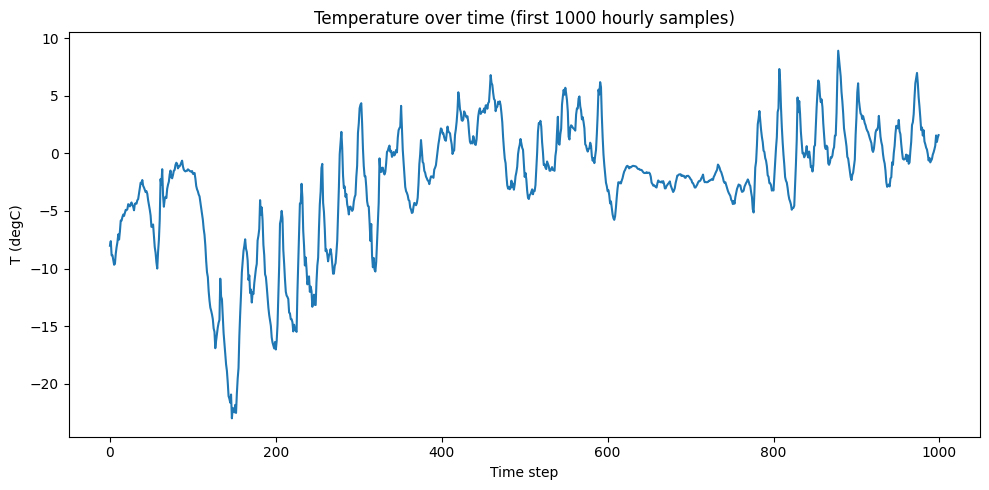

In [6]:
plt.plot(data[target_col].values[:1000])
plt.title("Temperature over time (first 1000 hourly samples)")
plt.xlabel("Time step")
plt.ylabel(target_col)
plt.tight_layout()
plt.show()

## Chronological split

I split chronologically. I do not shuffle time series before splitting.

In [7]:
n = len(data)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = data.iloc[:train_end].copy()
val_df = data.iloc[train_end:val_end].copy()
test_df = data.iloc[val_end:].copy()

scaler = StandardScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_df), columns=feature_cols)
val_scaled = pd.DataFrame(scaler.transform(val_df), columns=feature_cols)
test_scaled = pd.DataFrame(scaler.transform(test_df), columns=feature_cols)

## Sliding windows

I convert the continuous series into supervised samples.

For each sample:
- I use the last 24 hours as input
- I predict temperature 6 hours ahead

In [8]:
LOOKBACK = 24
HORIZON = 6
target_idx = feature_cols.index(target_col)

def make_windows(frame, lookback=24, horizon=6, target_idx=1):
    X, y = [], []
    values = frame.values
    for start in range(len(values) - lookback - horizon + 1):
        end = start + lookback
        target_time = end + horizon - 1
        X.append(values[start:end])
        y.append(values[target_time, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = make_windows(train_scaled, LOOKBACK, HORIZON, target_idx)
X_val, y_val = make_windows(val_scaled, LOOKBACK, HORIZON, target_idx)
X_test, y_test = make_windows(test_scaled, LOOKBACK, HORIZON, target_idx)

print(X_train.shape, y_train.shape)

(49035, 24, 14) (49035,)


## ConvLSTM reshape

ConvLSTM expects 5D input:
(batch, time, rows, cols, channels)

I reshape each feature vector at each time step into a tiny 1 x features frame.

In [9]:
def reshape_for_convlstm(X):
    return X.reshape(X.shape[0], X.shape[1], 1, X.shape[2], 1)

X_train_conv = reshape_for_convlstm(X_train)
X_val_conv = reshape_for_convlstm(X_val)
X_test_conv = reshape_for_convlstm(X_test)

print(X_train_conv.shape)

(49035, 24, 1, 14, 1)


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_regression(model, X, y, name):
    preds = model.predict(X, verbose=0).reshape(-1)

    mae = mean_absolute_error(y, preds)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, preds)

    print(f"{name} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

    return preds, {
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    plt.figure()
    plt.plot(hist["loss"], label="train loss")
    plt.plot(hist["val_loss"], label="val loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## Baseline 1: Dense

I flatten the whole time window and let a dense model learn from it. This is my blunt baseline.

In [15]:
dense_model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, len(feature_cols))),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])
dense_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
dense_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 336)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        43,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,457 (201.00 KB)

 Trainable params: 51,457 (201.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.1286 - val_loss: 56.5441
Epoch 2/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0790 - val_loss: 59.8529
Epoch 3/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0728 - val_loss: 78.9004
Epoch 4/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0688 - val_loss: 70.9091
Epoch 5/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0667 - val_loss: 55.8023
Epoch 6/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0648 - val_loss: 69.1316
Epoch 7/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0631 - val_loss: 55.5780
Epoch 8/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0616 - val_loss: 43.9128
Epoch 9/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0604 - val_loss: 55.2576
Epoch 10/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0591 - val_loss: 64.8655
Epoch 11/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0586 - val_loss: 59.0321
Epoch 12/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 

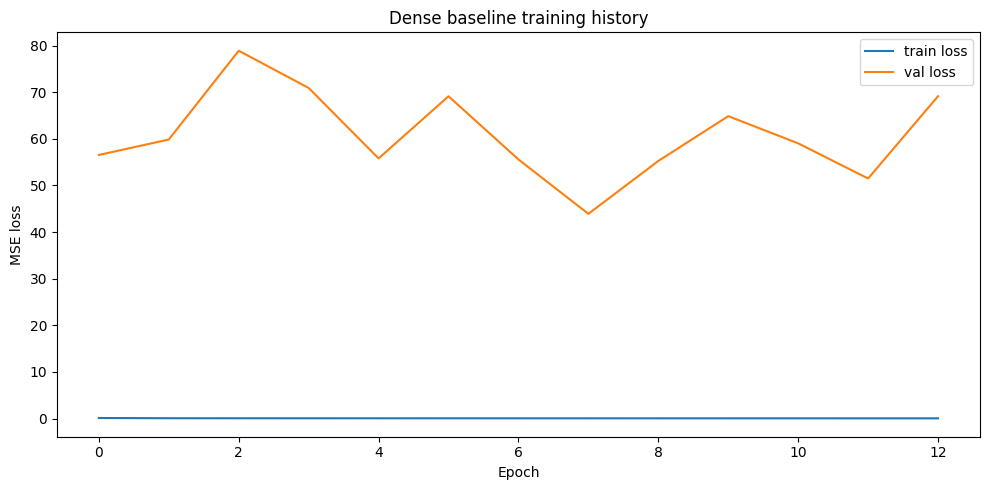

Dense | MAE: 0.1912 | RMSE: 0.2451 | R2: 0.9258


In [16]:
history_dense = dense_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
plot_history(history_dense, "Dense baseline training history")
pred_dense, score_dense = evaluate_regression(dense_model, X_test, y_test, "Dense")

## Baseline 2: LSTM

Now I use a sequence model that reads time in order and keeps memory.

In [17]:
lstm_model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, len(feature_cols))),
    layers.LSTM(64),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])
lstm_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,337 (87.25 KB)

 Trainable params: 22,337 (87.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 0.1095 - val_loss: 0.0733
Epoch 2/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0712 - val_loss: 0.0659
Epoch 3/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0657 - val_loss: 0.0634
Epoch 4/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0630 - val_loss: 0.0612
Epoch 5/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0598 - val_loss: 0.0603
Epoch 6/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 0.0581 - val_loss: 0.0609
Epoch 7/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0565 - val_loss: 0.0594
Epoch 8/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0547 - val_loss: 0.0606
Epoch 9/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0537 - val_loss: 0.0594
Epoch 10/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0522 - val_loss: 0.0588
Epoch 11/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 0.0517 - val_loss: 0.0580
Epoch 12/25
767/767 ━━━━━━━━━━

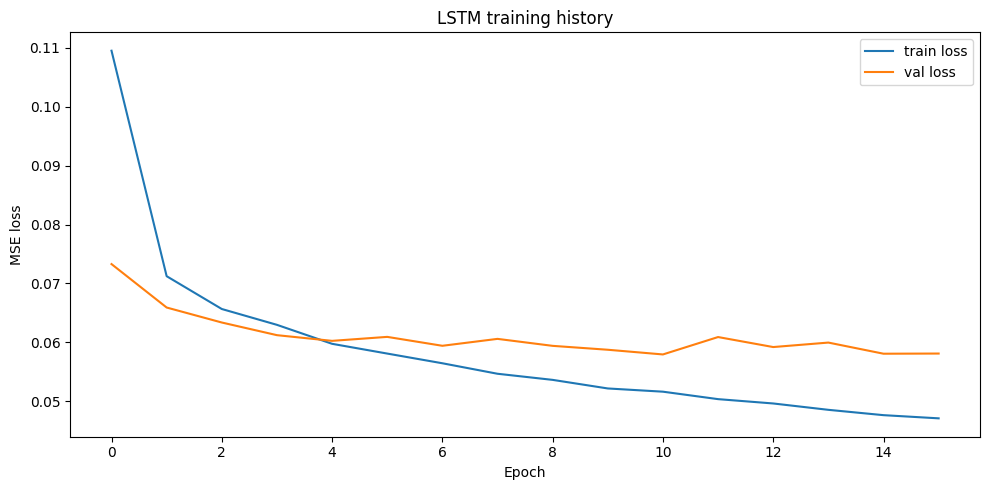

LSTM | MAE: 0.1716 | RMSE: 0.2232 | R2: 0.9384


In [18]:
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
plot_history(history_lstm, "LSTM training history")
pred_lstm, score_lstm = evaluate_regression(lstm_model, X_test, y_test, "LSTM")

## Baseline 3: ConvLSTM

This is the main model I want to understand.

It tracks time like a recurrent model and uses convolution inside each frame. For spectra, that matters because neighboring wavelengths are locally related.

In [19]:
convlstm_model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, 1, len(feature_cols), 1)),
    layers.ConvLSTM2D(
        filters=16,
        kernel_size=(1, 3),
        activation="tanh",
        padding="same",
        return_sequences=False
    ),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1)
])
convlstm_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
convlstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 1, 14, 16)      │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 14, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         7,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,625 (41.50 KB)

 Trainable params: 10,593 (41.38 KB)

 Non-trainable params: 32 (128.00 B)

Epoch 1/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 50s 56ms/step - loss: 0.1531 - val_loss: 0.0910
Epoch 2/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - loss: 0.1050 - val_loss: 0.0803
Epoch 3/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - loss: 0.0958 - val_loss: 0.0749
Epoch 4/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step - loss: 0.0906 - val_loss: 0.0737
Epoch 5/25
767/767 ━━━━━━━━━━━━━━━━━━━━ 42s 55ms/step - loss: 0.0853 - val_loss: 0.0732


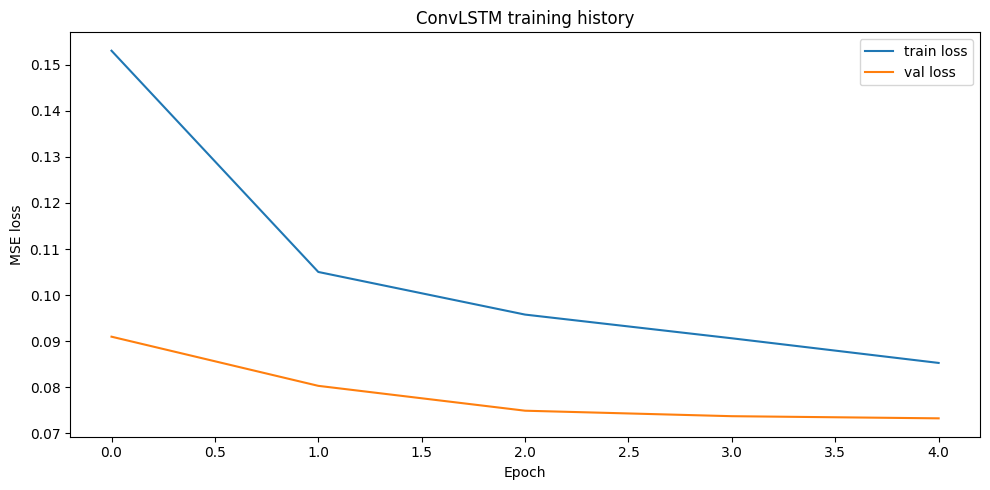

ConvLSTM | MAE: 0.2166 | RMSE: 0.2788 | R2: 0.9040


In [20]:
history_convlstm = convlstm_model.fit(
    X_train_conv, y_train,
    validation_data=(X_val_conv, y_val),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
plot_history(history_convlstm, "ConvLSTM training history")
pred_convlstm, score_convlstm = evaluate_regression(convlstm_model, X_test_conv, y_test, "ConvLSTM")

## Compare all models

I do not care about the architecture name if it does not actually help.

In [21]:
results_df = pd.DataFrame([score_dense, score_lstm, score_convlstm]).sort_values("RMSE")
results_df

,model,MAE,RMSE,R2
1,LSTM,0.171602,0.223248,0.938445
0,Dense,0.191227,0.245067,0.925825
2,ConvLSTM,0.216622,0.278787,0.904009


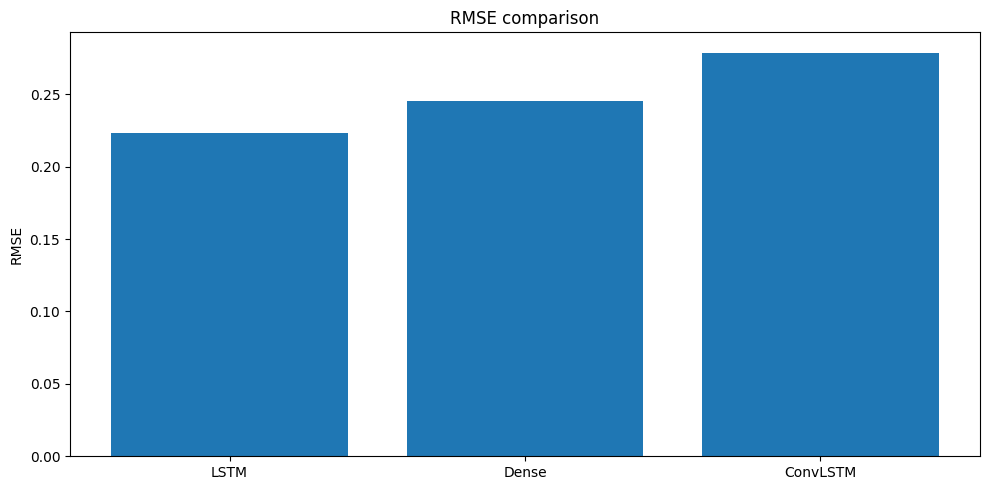

In [22]:
plt.figure()
plt.bar(results_df["model"], results_df["RMSE"])
plt.title("RMSE comparison")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

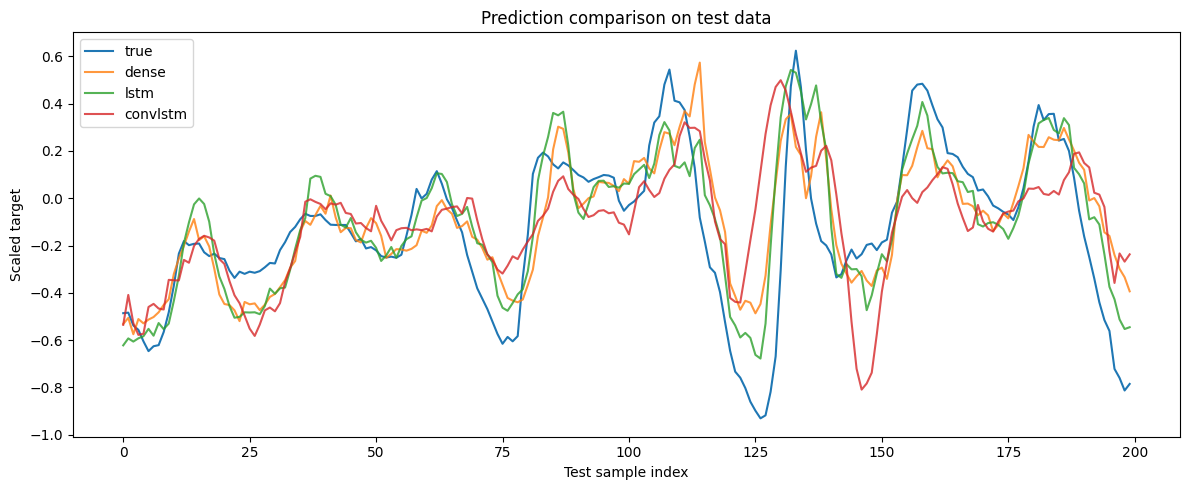

In [23]:
n_plot = 200
plt.figure(figsize=(12, 5))
plt.plot(y_test[:n_plot], label="true")
plt.plot(pred_dense[:n_plot], label="dense", alpha=0.8)
plt.plot(pred_lstm[:n_plot], label="lstm", alpha=0.8)
plt.plot(pred_convlstm[:n_plot], label="convlstm", alpha=0.8)
plt.title("Prediction comparison on test data")
plt.xlabel("Test sample index")
plt.ylabel("Scaled target")
plt.legend()
plt.tight_layout()
plt.show()

## How I would translate this to tissue engineering

Once I understand this notebook properly, the next step is straightforward:

- replace the public time-series dataset with longitudinal tissue-engineering measurements
- let each time step contain a spectral vector or compact feature vector
- predict a future biomarker, maturity score, or time-to-threshold
- compare whether dense, LSTM, or ConvLSTM handles the trajectory best

In [24]:
dense_model.save(OUTPUT_DIR / "dense_baseline.keras")
lstm_model.save(OUTPUT_DIR / "lstm_baseline.keras")
convlstm_model.save(OUTPUT_DIR / "convlstm_baseline.keras")
results_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
print("Saved outputs to:", OUTPUT_DIR.resolve())

Saved outputs to: C:\Users\nosai\Downloads\outputs
